# WISE Infilling Example

Example of using proc_continuous to infill an arbitrary masked region of an image. This examples uses a subimage from the WISE 12 um dust map (tile 115).

Requires Julia Kernel

In [1]:
# Load needed packages

using Pkg
using FITSIO
using StatsBase
using CloudClean
using CairoMakie
using ColorSchemes
using OffsetArrays

In [2]:
#parameters. right click - format cell - mark as parameters
# This cell must be tagged with "parameters"

image_path = "default/image/path.fits"
mask_path = "default/mask/path.fits"
save_path = "default/save/path.fits"

"default/save/path.fits"

In [3]:
# Parameters
mask_path = "C:\\Users\\jhoffm72\\Documents\\FilPHANGS\\Data\\ngc0628_F770W\\Source_Removal\\_CDDfs0004pix_F770W_CDDfs_sources_S2N_mask.fits"
image_path = "C:\\Users\\jhoffm72\\Documents\\FilPHANGS\\Data\\OriginalImages\\ngc0628_F770W_JWST_Emission_starsub.fits"
save_path = "C:\\Users\\jhoffm72\\Documents\\FilPHANGS\\Data\\ngc0628_F770W\\Source_Removal\\OriginalImageSourcesRemoved.fits"
widx = 275


275

In [4]:
using FITSIO

# Open the FITS file safely
f = FITS(image_path)

# Function to safely extract image + header from possible HDU indices
function get_image_data(f::FITS)
    possible_hdus = [1, 2, 3, 0]  # try these HDUs in order
    for h in possible_hdus
        try
            hdu = f[h]
            # Check that this HDU actually contains image data
            if isa(hdu, ImageHDU)
                data = read(hdu)
                hdr = read_header(hdu)
                return data, hdr
            end
        catch e
            # Silently skip if index is out of range or unreadable
            continue
        end
    end
    error(" No valid ImageHDU found in FITS file. Tried HDUs [0,1,2,3].")
end

raw_image, header = get_image_data(f)

out_image = copy(raw_image)

out_image[isnan.(raw_image)] .= 0.0

close(f)


In [5]:
# Mask with missing pixels
f = FITS(mask_path)
raw_mask = read(f[1])
close(f)

# Convert the raw mask data into a boolean mask (True for masked pixels, False otherwise)
bimage = raw_mask .!= 0  # Create a boolean mask, True where non-zero

# Now bimage is a boolean array with True for masked pixels and False for unmasked pixels
println("Mask shape: ", size(bimage))

Mask shape: 

(1891, 2600)


In [6]:
Np = 15
out_image[bimage].= 0
count(bimage)

146762

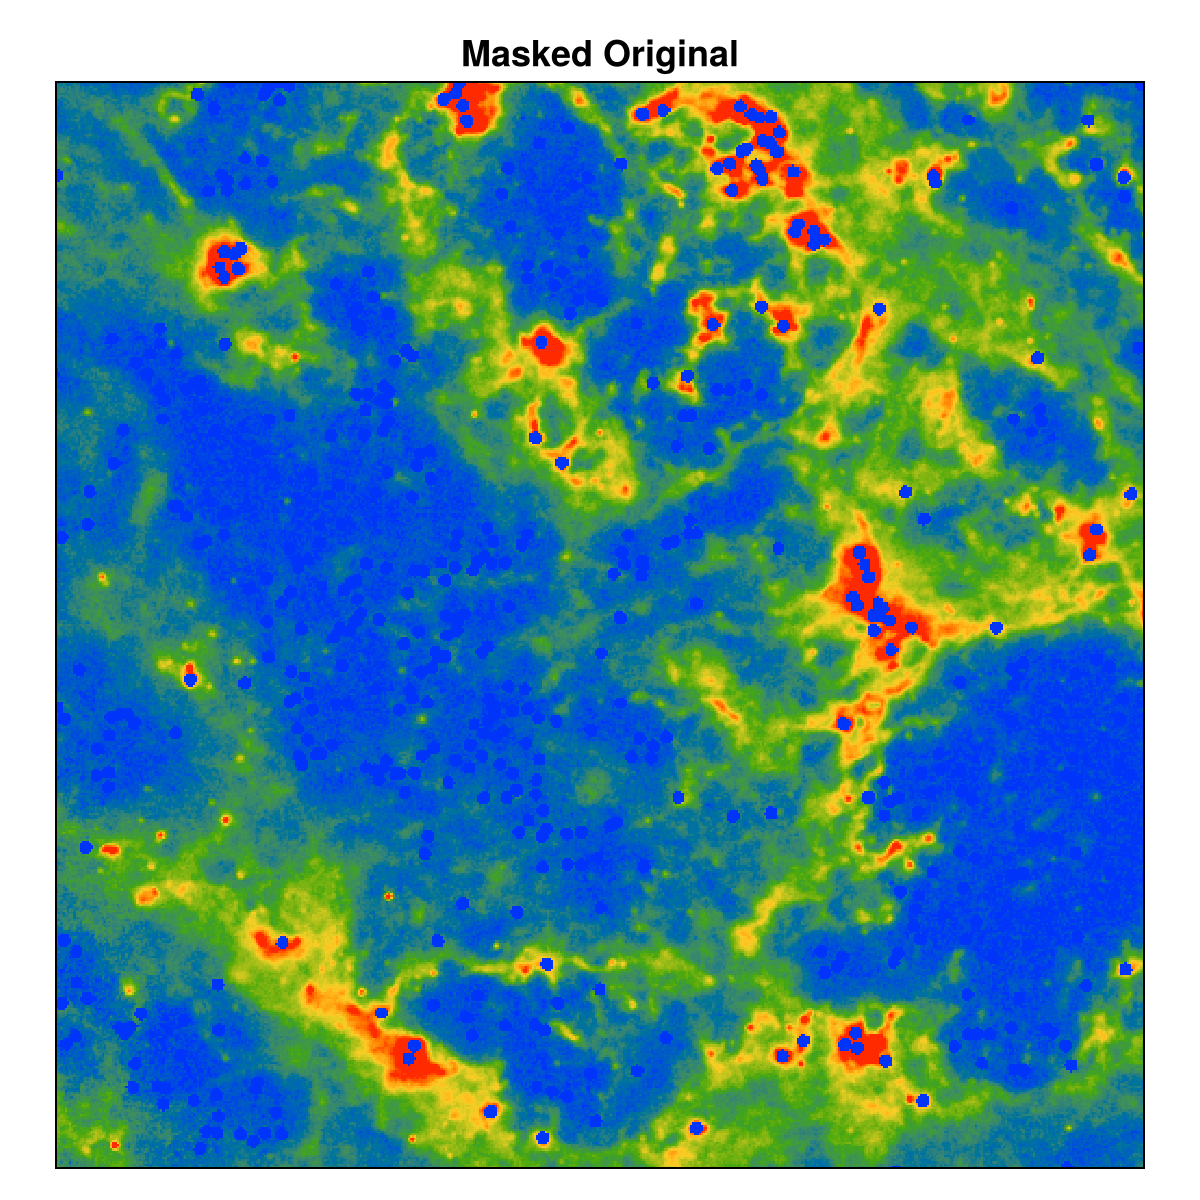

In [7]:
# Example values for cenx, ceny, and dv; adjust these based on your data
cenx = 579
ceny = 579
dv = 250

# Assuming raw_image is your image data and out_image is the image you want to display
# Compute the color range based on percentiles in a region around (cenx, ceny)
vmin, vmax = percentile(out_image[(cenx-dv):(cenx+dv), (ceny-dv):(ceny+dv)], [2, 99])

# Create a figure for plotting
fig = Figure(size=(600, 600), fontsize=18)

# Set up the axis with no ticks or labels
ax = Axis(fig[1,1], aspect=1, title="Masked Original", xticksvisible=false, yticksvisible=false, 
          xticklabelsvisible=false, yticklabelsvisible=false)

# Display the heatmap using the chosen colormap and the computed color range
h = heatmap!(ax, out_image[(cenx-dv):(cenx+dv), (ceny-dv):(ceny+dv)]',
    colormap=:rainbow_bgyr_35_85_c73_n256,
    colorrange=(vmin, vmax)
)

# Resize the figure to fit the layout
resize_to_layout!(fig)

# Show the figure
fig


In [8]:
ndraw0 = 2
x_locs = [cenx]
y_locs = [ceny]
star_stats = proc_continuous(out_image,bimage,Np=Np,tilex=4,ftype=64,widx=widx,seed=2022,ndraw=ndraw0)


# Debug: Check the structure of star_stats
if isa(star_stats, Tuple)
    println("star_stats is a tuple with length: ", length(star_stats))
    for i in 1:length(star_stats)
        println("star_stats[$i] has type: ", typeof(star_stats[i]), " and size: ", size(star_stats[i]))
    end
else
    println("star_stats is not a tuple. It has type: ", typeof(star_stats))
end

Infilling completed after 1 rounds with final width (widx,widy) = (27,27)


Finished 240 of 6936 locations in tile (1, 1)


Finished 334 of 9554 locations in tile (1, 2)


Finished 61 of 1773 locations in tile (1, 3)


Finished 0 of 0 locations in tile (1, 4)


...


Finished 389 of 11875 locations in tile (4, 3)

Finished 371 of 11281 locations in tile (4, 4)


star_stats is a tuple with length: 2
star_stats[1] has type: 

Matrix{

Float64} and size: (1891, 2600)
star_stats[2] has type: OffsetArray{Float64, 3, Array{Float64, 3}} and size: (1891, 2600, 2)


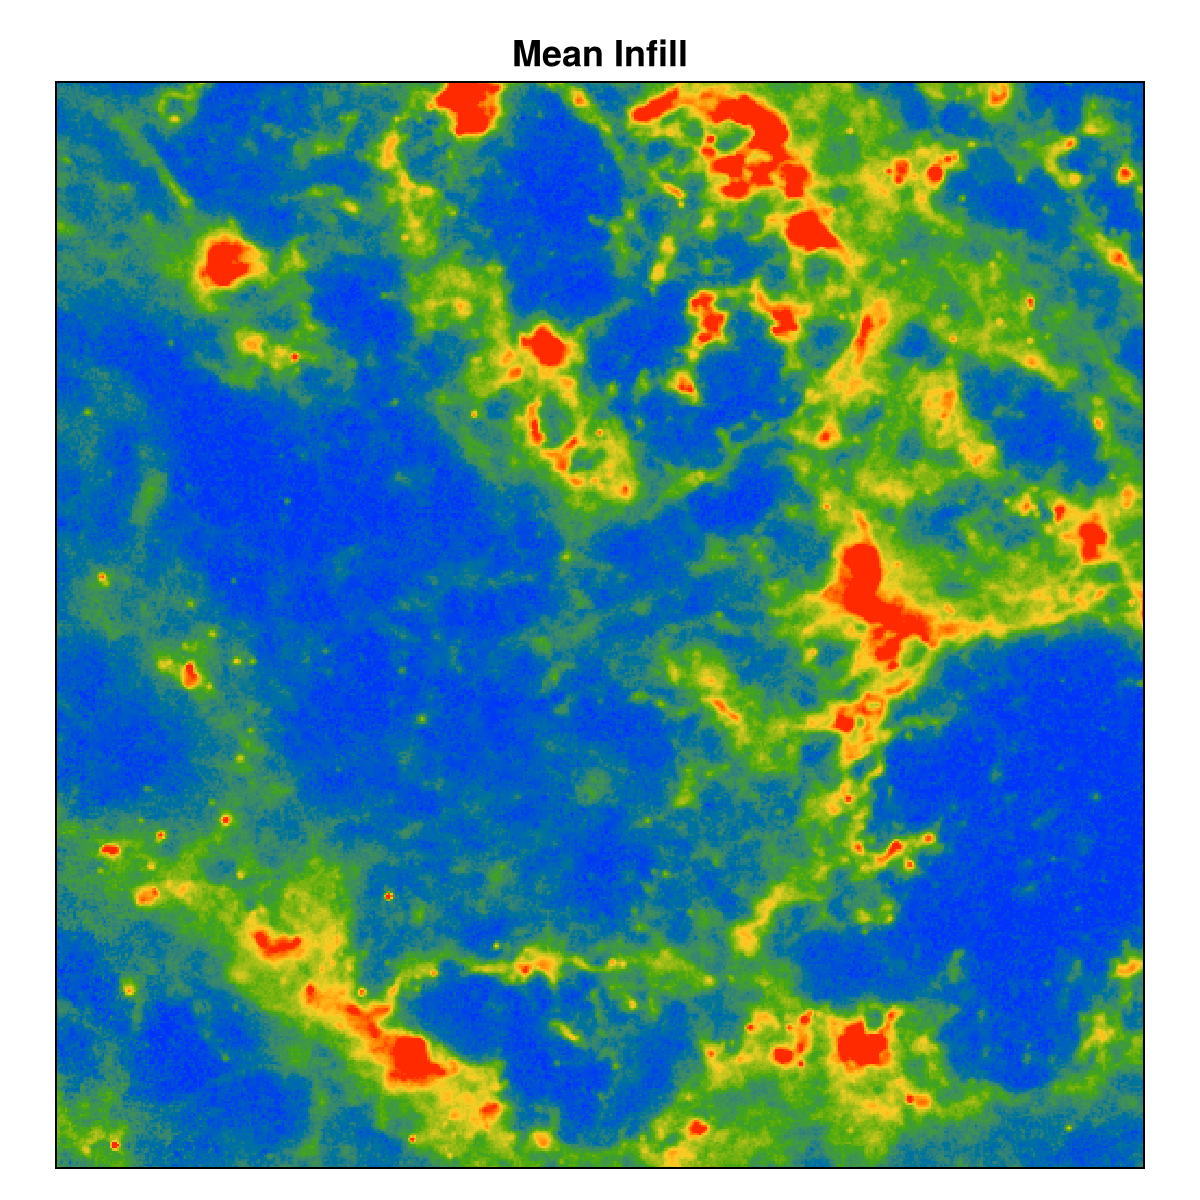

In [9]:
cenx = 579
ceny = 579
dv = 250
vmin, vmax = percentile(out_image[(cenx-dv):(cenx+dv),(ceny-dv):(ceny+dv)],[2,99])
fig = Figure(size=(600, 600), fontsize=18)
ax = Axis(fig[1,1], aspect=1, title="Mean Infill", xticksvisible=false, yticksvisible=false, 
          xticklabelsvisible=false, yticklabelsvisible=false)
h = heatmap!(ax,star_stats[1][(cenx-dv):(cenx+dv),(ceny-dv):(ceny+dv)]',
    colormap=:rainbow_bgyr_35_85_c73_n256,
    colorrange=(vmin,vmax)
)

resize_to_layout!(fig)
fig

In [10]:
dv = 250
fig = Figure(size=(600, 600), fontsize=18)
ax = Axis(fig[1,1], aspect=1, title="Draw Infill", xticksvisible=false, yticksvisible=false, 
          xticklabelsvisible=false, yticklabelsvisible=false)
h = heatmap!(ax,star_stats[2][(cenx-dv):(cenx+dv),(ceny-dv):(ceny+dv),1]',
    colormap=:rainbow_bgyr_35_85_c73_n256,
    colorrange=(vmin,vmax)
)

# Convert to a standard Array
array_data = max.(parent(star_stats[2]), 0)  # Set negative values to zero

# Open a FITS file and write
FITS(save_path, "w") do f
    write(f, convert(Array, array_data); header = header)  # Ensure it's a proper Array
end

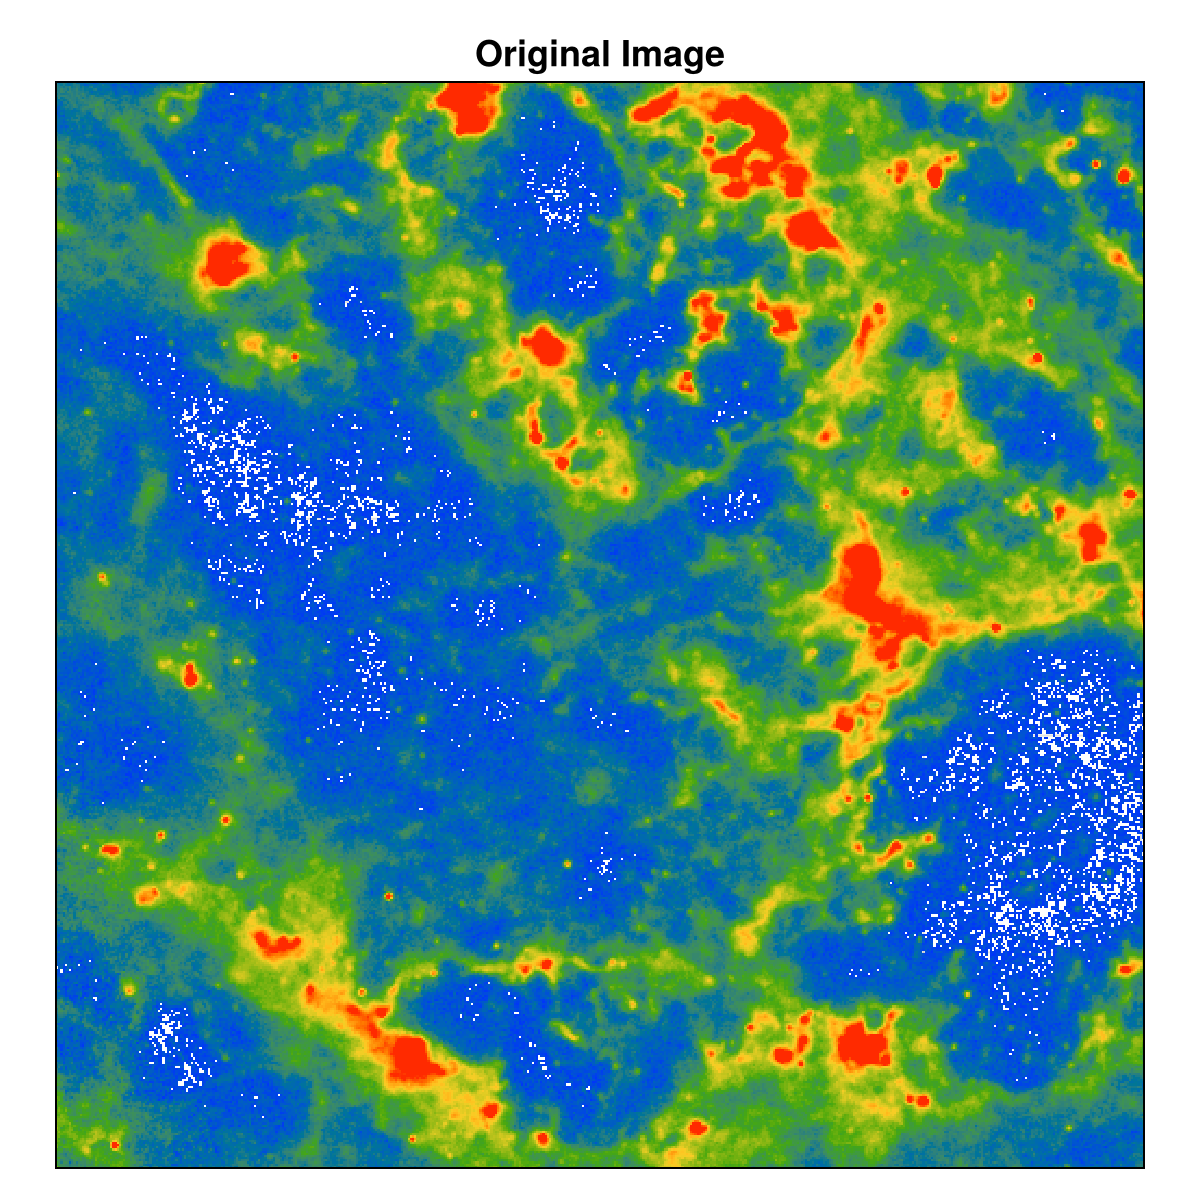

In [11]:
dv = 250
fig = Figure(size=(600, 600), fontsize=18)
ax = Axis(fig[1,1], aspect=1, title="Original Image", xticksvisible=false, yticksvisible=false, 
          xticklabelsvisible=false, yticklabelsvisible=false)
h = heatmap!(ax,raw_image[(cenx-dv):(cenx+dv),(ceny-dv):(ceny+dv)]',
    colormap=:rainbow_bgyr_35_85_c73_n256,
    colorrange=(vmin,vmax)
)

resize_to_layout!(fig)
fig